In [ ]:
!pip install -q ultralytics==8.4.79
import torch
import ultralytics
from ultralytics import YOLO

print("GPU:", torch.cuda.get_device_name(0))

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.7 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
GPU: Tesla T4


In [ ]:
from google.colab import drive
from pathlib import Path
from zipfile import ZipFile
drive.mount("/content/drive")
ZIP_PATH = Path("/content/drive/MyDrive/rock_project/Rock2026812.v7-rock_detection_509_v3.yolov11.zip")

with ZipFile(ZIP_PATH, "r") as zip_file:
    zip_file.extractall(Path("/content/rock_detection_509_v7"))

print("Dataset successfully decompressed")

Mounted at /content/drive
Dataset successfully decompressed


In [ ]:
data_yaml = Path("/content/rock_detection_509_v7") / "data.yaml"

yaml_text = (
    "path: /content/rock_detection_509_v7\n"
    "train: train/images\n"
    "val: valid/images\n"
    "test: test/images\n"
    "nc: 1\n"
    "names: {0: rock}\n"
)

data_yaml.write_text(yaml_text, encoding="utf-8")
Dataset_path=Path("/content/rock_detection_509_v7")

In [ ]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

expected = {
    "train": (359, 496),
    "valid": (74, 97),
    "test": (76, 97),
}

total_images=0
total_boxes=0

for split in expected:
    image_dir = Dataset_path / split / "images"
    label_dir = Dataset_path / split / "labels"

    images = [
        file for file in image_dir.iterdir()
        if file.is_file() and file.suffix.lower() in IMAGE_EXTENSIONS ]

    labels = list(label_dir.glob("*.txt"))
    box_count = 0
    for label_file in labels:
        lines = label_file.read_text(encoding="utf-8").splitlines()
        box_count = len([line for line in lines if line.strip()]) + box_count

    total_images = len(images) + total_images
    total_boxes = box_count+total_boxes

print("Dataset check completed.")
print("Total images:", total_images)
print("Total boxes:", total_boxes)

Dataset check completed.
Total images: 509
Total boxes: 690


In [ ]:
#yolov8s.pt
model = YOLO("yolov8s.pt")
train_results = model.train(
    data=str(data_yaml),
    epochs=100,
    patience=20,
    imgsz=640,
    batch=16,
    device=0,
    workers=2,
    optimizer="auto",
    amp=True,
    seed=42,
    deterministic=True,

    #Data augmentation consistent with YOLO11n
    hsv_h=0.015,
    hsv_s=0.40,
    hsv_v=0.30,

    degrees=5.0,
    translate=0.08,
    scale=0.20,
    shear=0.0,
    perspective=0.0,

    flipud=0.0,
    fliplr=0.5,

    mosaic=0.5,
    close_mosaic=10,

    project=str(Path("/content/drive/MyDrive/rock_project/runs")),
    name="yolov8s_detect_640_v7",
    exist_ok=False,
    plots=True,
    save=True
)

best_pt = Path(train_results.save_dir)/"weights"/"best.pt"
last_pt = Path(train_results.save_dir)/"weights"/"last.pt"

print("\nTraining complete.")
print("Training result location: ",Path(train_results.save_dir))
print("Best model: ", best_pt)
print("Last model: ", last_pt)


New https://pypi.org/project/ultralytics/8.4.129 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.79 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/rock_detection_509_v7/data.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.4, hsv_v=0.3, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.9

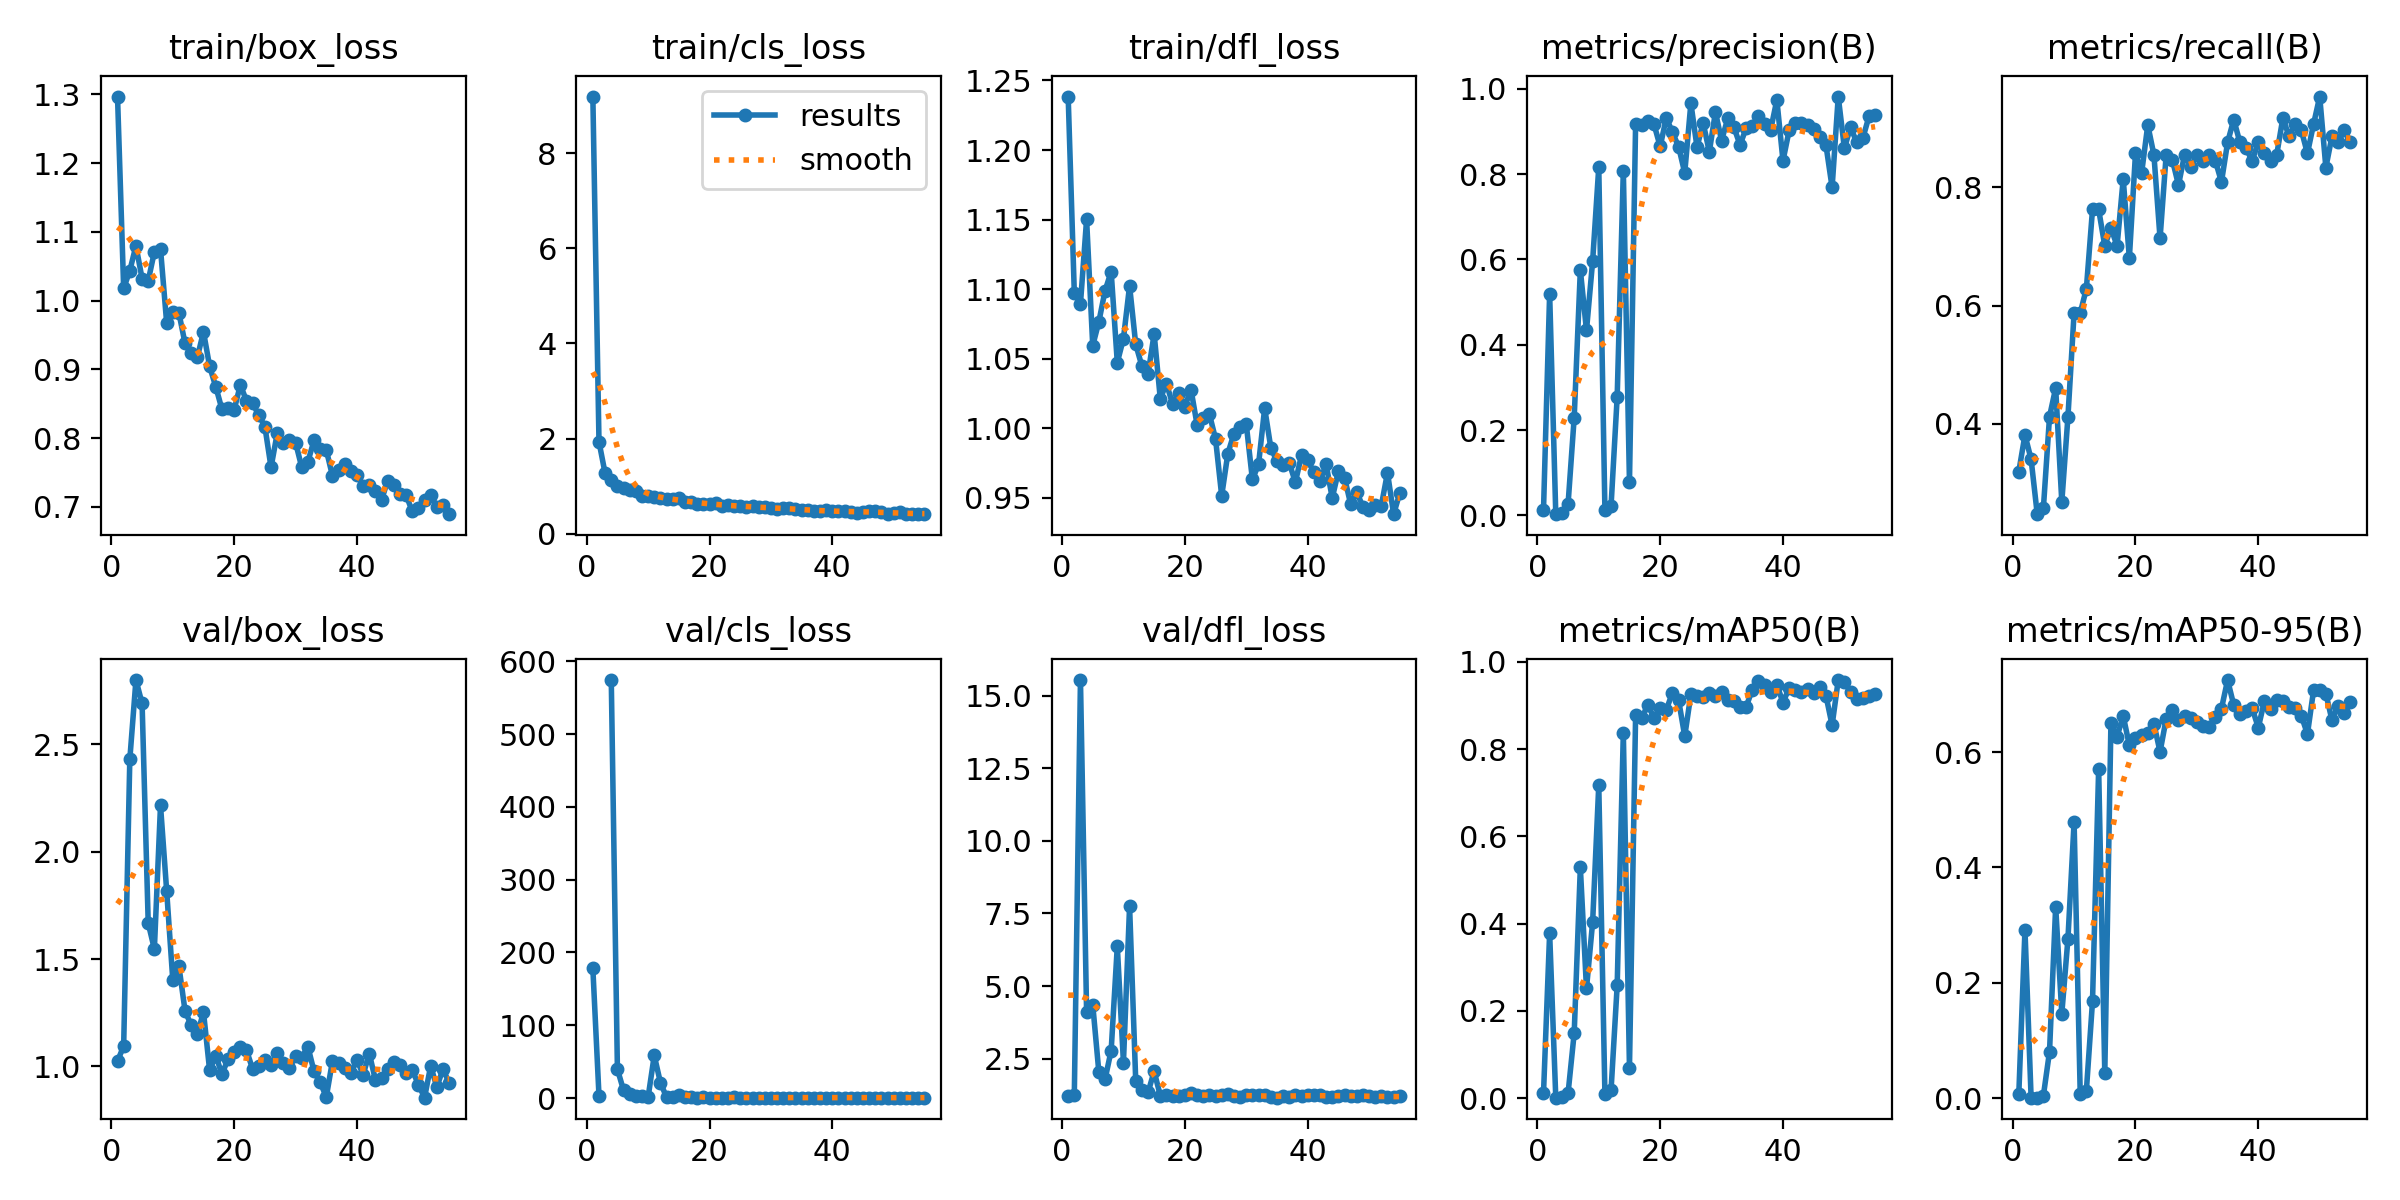

In [ ]:
from IPython.display import display,Image

run_path = Path(train_results.save_dir)
results_display = run_path / "results.png"
display(Image(filename=str(results_display)))


In [ ]:
best_model=YOLO(str(best_pt))
validation_metrics=best_model.val(
    data=str(data_yaml),
    split="val",

    imgsz=640,
    batch=16,
    device=0,
    plots=True,
    project=str(Path("/content/drive/MyDrive/rock_project/runs")/"validation"),
    name="yolov8s_detect_640_v7_val",
    exist_ok=True
)

print()
print("Validation results")
print(f"Precision : {validation_metrics.box.mp:.4f}")
print(f"Recall    : {validation_metrics.box.mr:.4f}")
print(f"mAP50     : {validation_metrics.box.map50:.4f}")
print(f"mAP50-95  : {validation_metrics.box.map:.4f}")

Ultralytics 8.4.79 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4224.4±755.7 MB/s, size: 2542.5 KB)
val: Scanning /content/rock_detection_509_v7/valid/labels.cache... 74 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 74/74 28.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.5s/it 7.6s
                   all         74         97      0.875      0.876      0.935      0.725
Speed: 8.1ms preprocess, 13.3ms inference, 0.0ms loss, 4.5ms postprocess per image
Results saved to /content/drive/MyDrive/rock_project/runs/validation/yolov8s_detect_640_v7_val

Validation results
Precision : 0.8749
Recall    : 0.8763
mAP50     : 0.9353
mAP50-95  : 0.7254


In [ ]:
test_metrics= best_model.val(
    data=str(data_yaml),
    split="test",
    imgsz=640,
    batch=16,
    device=0,
    plots=True,
    project=str(Path("/content/drive/MyDrive/rock_project/runs")/ "test"),
    name="yolov8s_detect_640_v7_test",
    exist_ok=True
)

print()
print("Final test results")
print(f"Precision : {test_metrics.box.mp:.4f}")
print(f"Recall    : {test_metrics.box.mr:.4f}")
print(f"mAP50     : {test_metrics.box.map50:.4f}")
print(f"mAP50-95  : {test_metrics.box.map:.4f}")

Ultralytics 8.4.79 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 221.1±44.0 MB/s, size: 3169.5 KB)
val: Scanning /content/rock_detection_509_v7/test/labels... 76 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 76/76 413.8it/s 0.2s
val: New cache created: /content/rock_detection_509_v7/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 2.0s/it 10.1s
                   all         76         97      0.955      0.897       0.95      0.754
Speed: 4.3ms preprocess, 10.0ms inference, 0.0ms loss, 2.2ms postprocess per image
Results saved to /content/drive/MyDrive/rock_project/runs/test/yolov8s_detect_640_v7_test

Final test results
Precision : 0.9545
Recall    : 0.8969
mAP50     : 0.9497
mAP50-95  : 0.7539


In [ ]:
predict_path = Path("/content/yolov8s_v7_predictions")
prediction_results=best_model.predict(
    source=str(Dataset_path/"test"/"images"),
    imgsz=640,
    conf=0.5,
    save=True,
    project=str(predict_path.parent),
    name=predict_path.name,
    exist_ok=True
)

print("The number of Predict images:", len(prediction_results))
print("Predict image location:", predict_path)


image 1/76 /content/rock_detection_509_v7/test/images/TST_RF000001_jpeg.rf.ab56c488c147cc7c2f49dd265fefc3ef.jpg: 480x640 1 rock, 47.2ms
image 2/76 /content/rock_detection_509_v7/test/images/TST_RF000002_jpeg.rf.1b8c6f734c6f44aab6dd3d625c4b5a3f.jpg: 480x640 1 rock, 12.9ms
image 3/76 /content/rock_detection_509_v7/test/images/TST_RF000003_jpeg.rf.04650f58ccb0124f29ffb2110bdcbbb1.jpg: 480x640 1 rock, 13.4ms
image 4/76 /content/rock_detection_509_v7/test/images/TST_RF000004_jpeg.rf.571ee223511400a51a9d4e394653c0f6.jpg: 640x480 1 rock, 47.7ms
image 5/76 /content/rock_detection_509_v7/test/images/TST_RF000006_jpeg.rf.f8a2cdee1584cacc0065cd4c6501be8c.jpg: 640x480 1 rock, 12.0ms
image 6/76 /content/rock_detection_509_v7/test/images/TST_RF000007_jpeg.rf.bc2c543a93dd0528a82e5d96a00c7aa9.jpg: 640x480 5 rocks, 21.0ms
image 7/76 /content/rock_detection_509_v7/test/images/TST_RF000008_jpeg.rf.d780d170273a970380fabd067d49161a.jpg: 640x480 5 rocks, 12.1ms
image 8/76 /content/rock_detection_509_v7/tes

In [ ]:
from PIL import Image as PILImage

for result in prediction_results[:10]:
    image=result.plot()[:, :, ::-1]
    display(PILImage.fromarray(image))

In [ ]:
import json

metrics_summary = {
    "model": "YOLOv8s",
    "pretrained_weights": "yolov8s.pt",
    "input_size": 640,

    "dataset": "Rock detection v7",
    "total_images": 509,
    "train_images": 359,
    "validation_images": 74,
    "test_images": 76,

    "maximum_epochs": 100,
    "batch_size": 16,
    "patience": 20,
    "seed": 42,

    "validation": {
        "mAP50": float(validation_metrics.box.map50),
        "mAP50_95": float(validation_metrics.box.map),
        "precision": float(validation_metrics.box.mp),
        "recall": float(validation_metrics.box.mr),
    },

    "test": {
        "mAP50": float(test_metrics.box.map50),
        "mAP50_95": float(test_metrics.box.map),
        "precision": float(test_metrics.box.mp),
        "recall": float(test_metrics.box.mr),
    },

    "best_model": str(best_pt),
    "run_directory": str(run_path),
}

summary_path = run_path / "metrics_summary.json"

with open(summary_path, "w", encoding="utf-8") as file:
    json.dump(metrics_summary, file, indent=2)

print(json.dumps(metrics_summary, indent=2))
print("\nSummary saved:", summary_path)

{
  "model": "YOLOv8s",
  "pretrained_weights": "yolov8s.pt",
  "input_size": 640,
  "dataset": "Rock detection v7",
  "total_images": 509,
  "train_images": 359,
  "validation_images": 74,
  "test_images": 76,
  "maximum_epochs": 100,
  "batch_size": 16,
  "patience": 20,
  "seed": 42,
  "validation": {
    "mAP50": 0.9353489196062257,
    "mAP50_95": 0.725352631580336,
    "precision": 0.8748796621234047,
    "recall": 0.8762886597938144
  },
  "test": {
    "mAP50": 0.9496915210755684,
    "mAP50_95": 0.7538968263716923,
    "precision": 0.9545026829793966,
    "recall": 0.8969072164948454
  },
  "best_model": "/content/drive/MyDrive/rock_project/runs/yolov8s_detect_640_v7-4/weights/best.pt",
  "run_directory": "/content/drive/MyDrive/rock_project/runs/yolov8s_detect_640_v7-4"
}

Summary saved: /content/drive/MyDrive/rock_project/runs/yolov8s_detect_640_v7-4/metrics_summary.json


In [ ]:
import shutil
#Copy results

shutil.rmtree(Path("/content/yolov8s_detect_640_v7_results"),ignore_errors=True)
Path("/content/yolov8s_detect_640_v7_results").mkdir(parents=True)


shutil.copytree(
    run_path,
    Path("/content/yolov8s_detect_640_v7_results") / "training")

VAL_run_path = Path("/content/drive/MyDrive/rock_project/runs") / "validation" / "yolov8s_detect_640_v7_val"

if VAL_run_path.exists():
    shutil.copytree(
        VAL_run_path,
        Path("/content/yolov8s_detect_640_v7_results") / "validation"
    )

TEST_run_path = Path("/content/drive/MyDrive/rock_project/runs") / "test" / "yolov8s_detect_640_v7_test"

if TEST_run_path.exists():
    shutil.copytree(
        TEST_run_path,
        Path("/content/yolov8s_detect_640_v7_results") / "test"
    )

if predict_path.exists():
    shutil.copytree(
        predict_path,
        Path("/content/yolov8s_detect_640_v7_results") / "predictions",)

output = shutil.make_archive(
    "/content/yolov8s_detect_640_v7_results",
    "zip",
    root_dir=str(Path("/content/yolov8s_detect_640_v7_results"))
)

print("result_zip: ", output)

result_zip:  /content/yolov8s_detect_640_v7_results.zip


In [ ]:
from google.colab import files

files.download("/content/yolov8s_detect_640_v7_results.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
files.download(str(best_pt))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>